## Equação da Onda Elástica de 1ª ordem

A Equação da Onda Elástica de 1ª ordem na formulação tensão-velocidade de partícula no espaço bidimensional (plano X,Y), na sua forma expandida, pode ser obtida através da aplicação da Lei de Hooke e da Segunda Lei de Newton e pode ser escrita como:

\begin{equation}
\left\{\begin{array}{ll} 
\dfrac{\partial \tau_{xx}}{\partial t} - (\lambda+2\mu)\dfrac{\partial v_{x}}{\partial x}-\lambda\dfrac{\partial v_{z}}{\partial z}=f_{\tau_{xx}},\\
\dfrac{\partial\tau_{zz}}{\partial t}-(\lambda+2\mu)\dfrac{\partial v_{z}}{\partial z} -\lambda\dfrac{\partial v_{x}}{\partial x}=f_{\tau_{zz}},\\
\dfrac{\partial \tau_{zx}}{\partial t} -\mu\Big(\dfrac{\partial v_{x}}{\partial z} + \dfrac{\partial v_{z}}{\partial x}\Big) = f_{\tau_{zx}},\\
\rho\dfrac{\partial v_x}{\partial t} - \Big(\dfrac{\partial \tau_{xx}}{\partial x} + \dfrac{\partial \tau_{xz}}{\partial z} )=0,\\
\rho\dfrac{\partial v_z}{\partial t} - \Big(\dfrac{\partial \tau_{zx}}{\partial x}+\dfrac{\partial \tau_{zz}}{\partial z}\Big)=0 .
\end{array}\right.
\end{equation}

onde $\vec{v}=(v_x,~v_z)$ são as velocidades de partícula no eixo x e no eixo z, $\tau = (\tau_{xx},~\tau_{zz},~\tau_{xz}$) são as tensões, $f=$($f_{\tau_{xx}},~f_{\tau_{xx}})$ são os termos fonte, $\rho$ é a densidade e $\lambda$ e $\mu$ são os Parâmetros Elásticos de Lamé.


Considerando a matriz de rigidez ${\bf C}$ do caso isotrópico na notação de Voigt e a matriz ${\bf D}$ de derivadas espaciais descritas abaixo:

\begin{equation}
\begin{split}
   {\bf C}=\left(\begin{array}{ccc}
   \lambda+2 \mu & \lambda & 0 \\
   \lambda & \lambda+2 \mu & 0 \\ 
   0 & 0 & \mu \end{array}\right)~~\text{e}~~
{\bf D}=\left(\begin{array}{ccc}  
\dfrac{\partial}{\partial x}& 0 &\dfrac{\partial}{\partial z} \\
0 &  \dfrac{\partial}{\partial z}&\dfrac{\partial}{\partial x}
\end{array}\right)  .
\end{split}
\end{equation}

É possível reescrever a Equação da Onda Elástica de 1ª ordem da formulação tensão-velocidade de partícula na sua forma compacta:

\begin{equation}
     \left\{\begin{array}{l}\rho \dfrac{\partial \vec{v}}{\partial t}-{\bf D} \tau=0,\\ 
     \dfrac{\partial \tau}{\partial t}-{\bf C D}^{T} \vec{v}=f_\tau, \end{array}\right.
\end{equation}

Observação: em sua formulação compacta, o tensor de tensões $(\tau)$ é representado da seguinte forma:

\begin{equation}
\tau=\left(\begin{array}{c}
 \tau_{xx}  \\ 
 \tau_{zz}  \\ 
 \tau_{zx}
\end{array}\right)
\end{equation}

Observação: é comum encontrar a matriz de rigidez formulada em função de outros termos, como por exemplo em função da impedância acústica compressional $I_p$ e da impedância acústica cisalhante $I_s$, que são propriedades oriundas das velocidades compressionais e cisalhantes, respectivamente:

\begin{equation}
I_p=\rho V_p
\end{equation}
\begin{equation}
I_s=\rho V_s
\end{equation}

dentre outras. No caso da formulação da matriz de rigidez em função de $I_p$ e $I_s$, por exemplo, trata-se apenas de uma conversão, já que as velocidades compressional $V_p$ e cisalhante $V_s$ podem ser escritas em função dos parâmetros de Lamé e substituindo para essa outra formulação da matriz de rigidez, por exemplo. Por facilidade de implementação, usaremos a matriz de rigidez em função das impedâncias $I_p$ e $I_s$.

In [1]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
%matplotlib inline

from devito import *
from examples.seismic import *
from examples.seismic.stiffness import iso_elastic_setup
from examples.seismic.stiffness.model import ISOSeismicModel
from examples.seismic.stiffness.utils import C_Matrix, D, S, vec

from devito import configuration, norm

Operator `initdamp` ran in 0.01 s


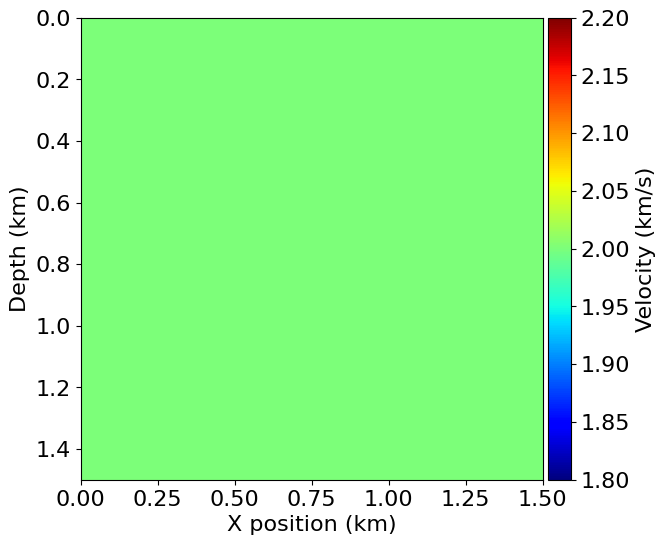

In [2]:
nx, nz = 601, 601
dx, dz = 2.5, 2.5

# Devido a limitação de poder computacional, limitei minha malha a 875 m x 875 m para preservar o espaçamento indicado de 2,5.

# Definindo o tamanho do modelo físico
shape = (nx, nz)  # Número de pontos da malha (nx, nz)
spacing = (dx, dz)  # Espaçamento, em metros, entre os pontos da malha. 
origin = (0., 0.)  # Localização do canto superior esquerdo?
space_order=2
nbl=100


# Definie o modelo de velocidade em km/s
vp = np.ones(shape, dtype=np.float32)*2 # = 2000 m/s
vs = np.ones(shape, dtype=np.float32)   # = 1000 m/s
rho = np.ones(shape,dtype=np.float32)*2 # = 2g/cc
b = 1./rho # sem significado fisico, b é o inverso da densidade
dtype = np.float32

model = ISOSeismicModel(vp=vp, vs=vs, b=b, origin=origin, space_order=space_order,
                     shape=shape, dtype=dtype, spacing=spacing, nbl=nbl)

plot_velocity(model)

In [3]:
from examples.seismic import TimeAxis

t0 = 0.  # Simulação começa em t = 0 ms
tn = 2000.  # Simulação dura até t = 2000 ms (t = 2s)
dt = model.critical_dt  # Passo (infinitesimal de tempo) do modelo ao longo do espaçamento do grid
f0 = 0.01  # Frequência de pico da wavelet (20Hz = 0.020 kHz)
damp = model.damp

time_range = TimeAxis(start=t0, stop=tn, step=dt)  # Define-se a função time_range com as informações inseridas acima
geometry = setup_geometry(model, tn, f0=f0)
nt = time_range.num  # Número de passos a serem tomados ao longo do grid

In [4]:
s = model.grid.stepping_dim.spacing
s

dt

In [5]:
nt

2264

In [6]:
dt

0.8839

In [7]:
0.8397*2383 ### = 2000, a diferença é porque 0.8839 está aproximado na quarta casa decimal

2001.0051

In [8]:
rho

array([[2., 2., 2., ..., 2., 2., 2.],
       [2., 2., 2., ..., 2., 2., 2.],
       [2., 2., 2., ..., 2., 2., 2.],
       ...,
       [2., 2., 2., ..., 2., 2., 2.],
       [2., 2., 2., ..., 2., 2., 2.],
       [2., 2., 2., ..., 2., 2., 2.]], dtype=float32)

In [9]:
rho = 1/model.b

In [10]:
rho

1/b(x, y)

In [11]:
# Função que define fonte e receptor
def source_rec_term1(model, tau, v0, pos):
    src = RickerSource(name='src', grid=model.grid, f0=f0, time_range=time_range)
    src.coordinates.data[0, :] = pos[0]  # posição da fonte na dimensão offset  [X]
    src.coordinates.data[0, -1] = pos[0] # posição da fonte na dimensão profundidade [Z]

    # Dá nome aos receptores
    rec_vx = Receiver(name='rec_vx', grid=model.grid, npoint=shape[0],
                      time_range=time_range)
    rec_vz = Receiver(name='rec_vz', grid=model.grid, npoint=shape[0],
                      time_range=time_range)
    rec_tau = Receiver(name='rec_tau', grid=model.grid, npoint=shape[0],
                         time_range=time_range)

    # Espaçamento dos receptores ao longo do eixo x e profundidade
    rec_vx.coordinates.data[:, 0] = np.linspace(0, model.domain_size[0], num=shape[0])
    rec_vx.coordinates.data[:, 1] = 0

    rec_vz.coordinates.data[:, 0] = np.linspace(0, model.domain_size[0], num=shape[0])
    rec_vz.coordinates.data[:, 1] = 0

    rec_tau.coordinates.data[:, 0] = np.linspace(0, model.domain_size[0], num=shape[0])
    rec_tau.coordinates.data[:, 1] = 0

    # Injeção da fonte
    src_xx = src.inject(field=tau[0].forward, expr=src * s)
    src_term = src_xx

    # Só injetei a fonte no horizontal

    rec_term_vx = rec_vx.interpolate(expr=v0[0])
    rec_term_vz = rec_vz.interpolate(expr=v0[1])
    rec_expr = rec_term_vx + rec_term_vz

    expr = tau[0] + tau[1]
    rec_term_tau = rec_tau.interpolate(expr=expr)
    rec_expr += rec_term_tau

    return rec_vx, rec_vz, rec_tau, rec_expr, src_term, src

In [12]:
# Matriz de rigidez
#(em função da impedância de Vp e da impedância de Vs, por facilidade de implementação em comparação ao tutorial disponível)
C = C_Matrix(model,'Ip-Is-rho')
C

Matrix([
[                      Ip(x, y)*vp(x, y), Ip(x, y)*vp(x, y) - 2*Is(x, y)*vs(x, y),                 0],
[Ip(x, y)*vp(x, y) - 2*Is(x, y)*vs(x, y),                       Ip(x, y)*vp(x, y),                 0],
[                                      0,                                       0, Is(x, y)*vs(x, y)]])

In [13]:
def elastic_forward1(model, pos, **kwargs):

    v0 = VectorTimeFunction(name='v0', grid=model.grid, save=geometry.nt, time_order=1,
                            space_order=space_order)
    tau = TensorTimeFunction(name='tau', grid=model.grid, space_order=space_order,
                               save=geometry.nt, time_order=1)
    tau = vec(tau)

    pde_v = rho * v0.dt - D(tau)
    u_v = Eq(v0.forward, damp * solve(pde_v, v0.forward))

    pde_tau = tau.dt - C * S(v0.forward)
    u_tau = Eq(tau.forward, damp * solve(pde_tau, tau.forward))

    rec_vx, rec_vz, rec_tau, rec_expr, src_term, src = source_rec_term1(model, tau,
                                                                         v0, pos)

    op = Operator([u_v, u_tau] + src_term + rec_expr, subs=model.spacing_map)
    op(dt=dt, src=src, rec_vx=rec_vx, rec_vz=rec_vz, rec_tau=rec_tau, vp=model.vp, vs=model.vs, Ip=model.Ip, Is=model.Is)
    
    return rec_vx, rec_vz, rec_tau, v0, tau

In [14]:
#Gerando o tiro com a fonte no centro do modelo

pos = np.empty((1, 2), dtype=np.float32)
pos[0, 0] = model.domain_size[0] * .5

rec_vx, rec_vz, rec_tau, v, tau = elastic_forward1(model, pos[0])

Operator `Kernel` ran in 9.31 s


### Resposta da letra (A)

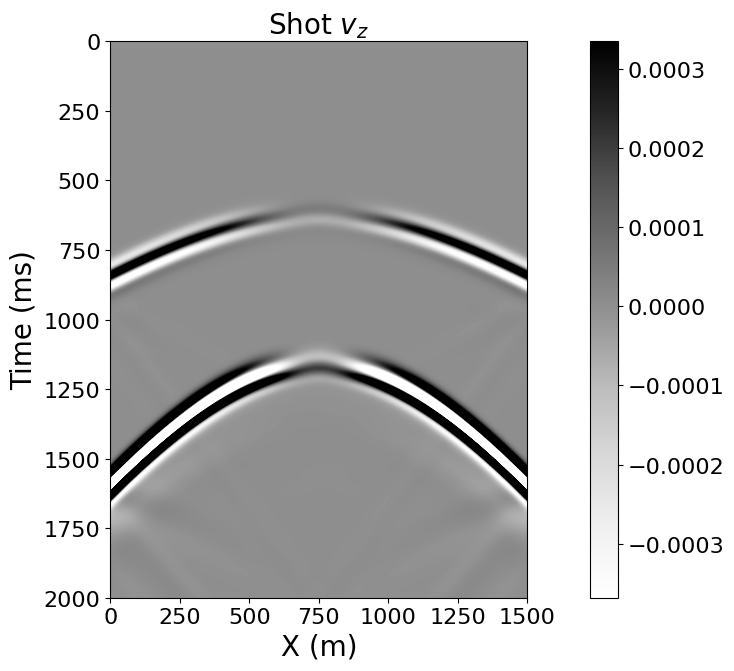

In [15]:
slices = [slice(model.nbl, -model.nbl), slice(model.nbl, -model.nbl)]

aspect_ratio = model.shape[0]/model.shape[1]

plt_options_model = {'cmap': 'Greys', 'extent': [model.origin[0], model.origin[0] + model.domain_size[0], tn, t0]}
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(13, 7))

scale = np.max(rec_vz.data) / 10.

scale2 = np.max(rec_vz.data) / 10.
img2 = ax.imshow(rec_vz.data, vmin=scale2, vmax=-scale2, **plt_options_model)
fig.colorbar(img2)
ax.set_title("Shot $v_z$", fontsize=20)
ax.set_xlabel('X (m)', fontsize=20)
ax.set_ylabel('Time (ms)', fontsize=20)

plt.tight_layout()

In [16]:
rho = 1/model.b

# Função que define fonte e receptor
def source_rec_term2(model, tau, v0, pos):
    src = RickerSource(name='src', grid=model.grid, f0=f0, time_range=time_range)
    src.coordinates.data[0, :] = pos[0]  # posição da fonte na dimensão offset  [X]
    src.coordinates.data[0, -1] = pos[0] # posição da fonte na dimensão profundidade [Z]

    # Dá nome aos receptores
    rec_vx = Receiver(name='rec_vx', grid=model.grid, npoint=shape[0],
                      time_range=time_range)
    rec_vz = Receiver(name='rec_vz', grid=model.grid, npoint=shape[0],
                      time_range=time_range)
    rec_tau = Receiver(name='rec_tau', grid=model.grid, npoint=shape[0],
                         time_range=time_range)

    # Espaçamento dos receptores ao longo do eixo x e profundidade
    rec_vx.coordinates.data[:, 0] = np.linspace(0, model.domain_size[0], num=shape[0])
    rec_vx.coordinates.data[:, 1] = 0

    rec_vz.coordinates.data[:, 0] = np.linspace(0, model.domain_size[0], num=shape[0])
    rec_vz.coordinates.data[:, 1] = 0

    rec_tau.coordinates.data[:, 0] = np.linspace(0, model.domain_size[0], num=shape[0])
    rec_tau.coordinates.data[:, 1] = 0

    # Injeção da fonte
    src_zz = src.inject(field=tau[1].forward, expr=src * s)
    src_term = src_zz

    # Só injetei a fonte no horizontal

    rec_term_vx = rec_vx.interpolate(expr=v0[0])
    rec_term_vz = rec_vz.interpolate(expr=v0[1])
    rec_expr = rec_term_vx + rec_term_vz

    expr = tau[0] + tau[1]
    rec_term_tau = rec_tau.interpolate(expr=expr)
    rec_expr += rec_term_tau

    return rec_vx, rec_vz, rec_tau, rec_expr, src_term, src

In [17]:
# Matriz de rigidez
#(em função da impedância de Vp e da impedância de Vs, por facilidade de implementação em comparação ao tutorial disponível)
C = C_Matrix(model,'Ip-Is-rho')
C

Matrix([
[                      Ip(x, y)*vp(x, y), Ip(x, y)*vp(x, y) - 2*Is(x, y)*vs(x, y),                 0],
[Ip(x, y)*vp(x, y) - 2*Is(x, y)*vs(x, y),                       Ip(x, y)*vp(x, y),                 0],
[                                      0,                                       0, Is(x, y)*vs(x, y)]])

In [18]:
def elastic_forward2(model, pos, **kwargs):

    v0 = VectorTimeFunction(name='v0', grid=model.grid, save=geometry.nt, time_order=1, space_order=space_order)
    tau = TensorTimeFunction(name='tau', grid=model.grid, space_order=space_order, save=geometry.nt, time_order=1)
    tau = vec(tau)

    pde_v = rho * v0.dt - D(tau)
    u_v = Eq(v0.forward, damp * solve(pde_v, v0.forward))

    pde_tau = tau.dt - C * S(v0.forward)
    u_tau = Eq(tau.forward, damp * solve(pde_tau, tau.forward))

    rec_vx, rec_vz, rec_tau, rec_expr, src_term, src = source_rec_term2(model, tau,
                                                                         v0, pos)

    op = Operator([u_v, u_tau] + src_term + rec_expr, subs=model.spacing_map)
    op(dt=dt, src=src, rec_vx=rec_vx, rec_vz=rec_vz, rec_tau=rec_tau, vp=model.vp, vs=model.vs, Ip=model.Ip, Is=model.Is)
    
    return rec_vx, rec_vz, rec_tau, v0, tau

In [19]:
#Gerando o tiro com a fonte no centro do modelo

pos = np.empty((1, 2), dtype=np.float32)
pos[0, 0] = model.domain_size[0] * .5

rec_vx, rec_vz, rec_tau, v0, tau = elastic_forward2(model, pos[0])

Operator `Kernel` ran in 8.55 s


### Resposta letra b)

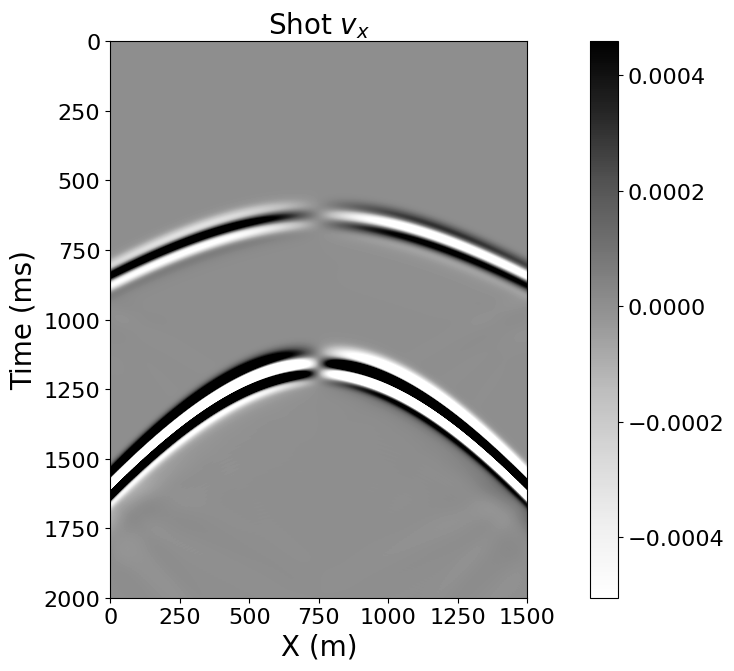

In [20]:
slices = [slice(model.nbl, -model.nbl), slice(model.nbl, -model.nbl)]

aspect_ratio = model.shape[0]/model.shape[1]

plt_options_model = {'cmap': 'Greys', 'extent': [model.origin[0], model.origin[0] + model.domain_size[0], tn, t0]}
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(13, 7))

scale = np.max(rec_vx.data) / 10.

scale2 = np.max(rec_vx.data) / 10.
img2 = ax.imshow(rec_vx.data, vmin=scale2, vmax=-scale2, **plt_options_model)
fig.colorbar(img2)
ax.set_title("Shot $v_x$", fontsize=20)
ax.set_xlabel('X (m)', fontsize=20)
ax.set_ylabel('Time (ms)', fontsize=20)

plt.tight_layout()

### Resposta letra (c)

No registro da componente vertical da velocidade de partícula $v_z$ da figura da letra (a), é possível ver notar que os receptores imediatamente acima da fonte tem dificuldade em registrar alguma perturbação. A explicação é que a deformação imposta pela força horizontal da fonte, deformou a Terra ao longo do eixo horizontal, direção na qual a perturbação mais se propagou.

Similarmente, no registro da componente horizontal da velocidade de partícula $v_x$ da figura da letra (b), é possível ver observar novamente a queda da amplitude nos receptores imediatamente acima da fonte, além da inversão de polaridade no ápice da frente de onda, para o caso da figura da letra (b).

In [21]:
rec_vx1, rec_vz1, rec_tau1, v01, tau1 = elastic_forward1(model, pos[0])
rec_vx2, rec_vz2, rec_tau2, v02, tau2 = elastic_forward2(model, pos[0])

Operator `Kernel` ran in 11.10 s
Operator `Kernel` ran in 9.21 s


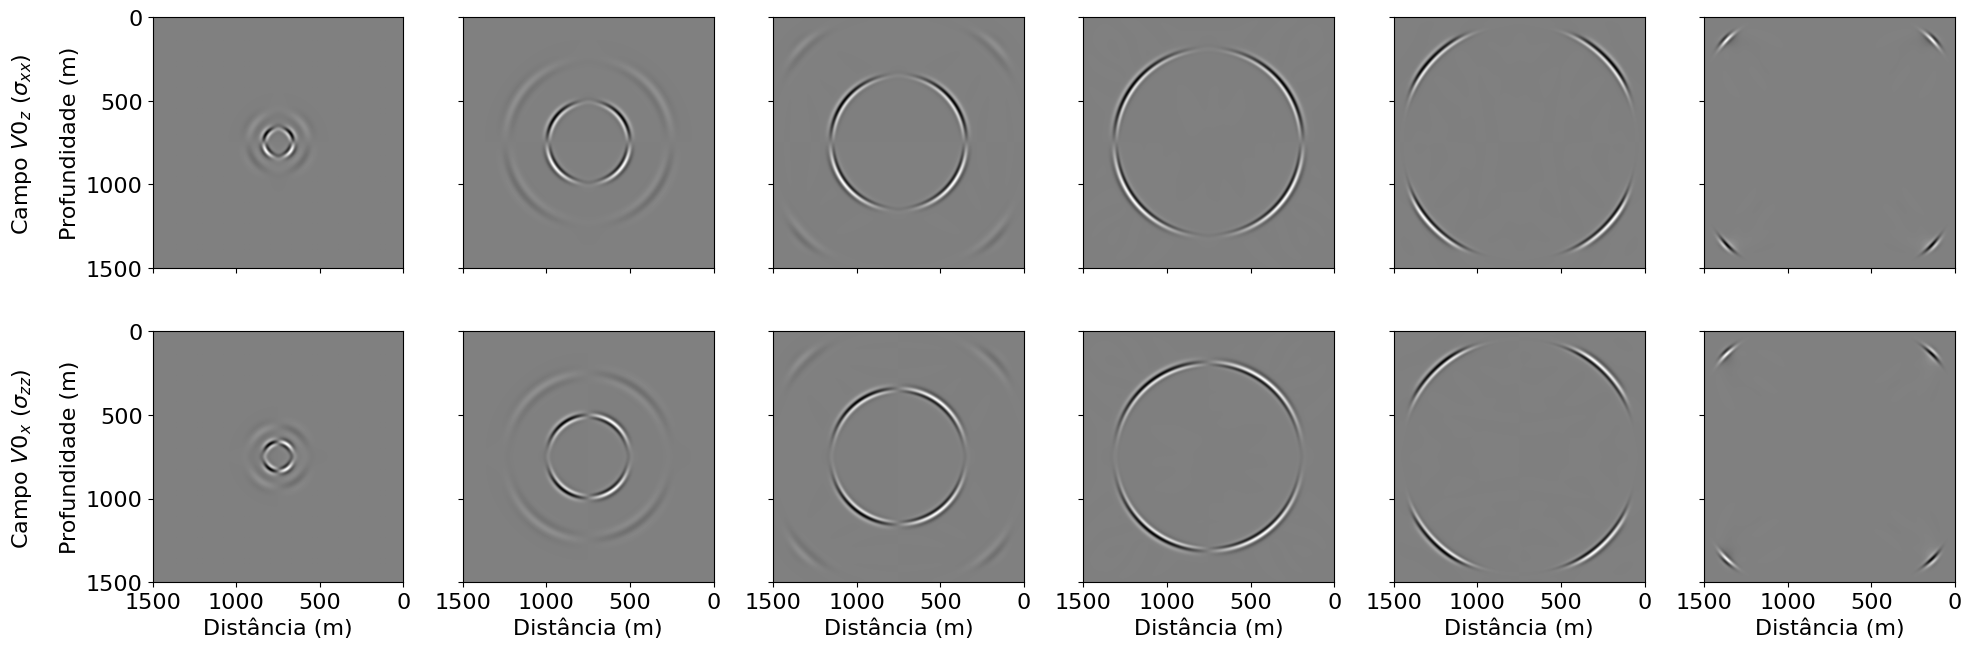

In [23]:
snaps = np.linspace(300, 2000, 6, dtype='int16')

plot_options = {'cmap':'gray', 'extent':[model.domain_size[0], 0, model.domain_size[1], 0]}
fig, axes = plt.subplots(2, 6, figsize=(20, 7), sharex=True, sharey=True)

[axes[0,i].imshow(v01[1].data[snap].T, **plot_options) for i, snap in enumerate(snaps)]
[axes[1,i].imshow(v02[0].data[snap].T, **plot_options) for i, snap in enumerate(snaps)]
axes[0,0].set_ylabel('Campo $V0_z$ ($\\sigma_{xx}$) \n\nProfundidade (m)')
axes[1,0].set_ylabel('Campo $V0_x$ ($\\sigma_{zz}$) \n\nProfundidade (m)')
[axes[1,i].set_xlabel('Distância (m)') for i in range(6)]

fig.tight_layout()
plt.show()